# Análisis Exploratorio de Datos — AI4I 2020

Este notebook realiza el análisis exploratorio del dataset AI4I 2020 Predictive Maintenance, utilizado para desarrollar un modelo de clasificación orientado a la detección de fallas en maquinaria industrial.

In [1]:
!pip install -q ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

dataset = fetch_ucirepo(id=601)
df = dataset.data.original

In [3]:
df.head()

,UID,Product ID,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 10000
Columnas: 14


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   UID                  10000 non-null  int64  
 1   Product ID           10000 non-null  object 
 2   Type                 10000 non-null  object 
 3   Air temperature      10000 non-null  float64
 4   Process temperature  10000 non-null  float64
 5   Rotational speed     10000 non-null  int64  
 6   Torque               10000 non-null  float64
 7   Tool wear            10000 non-null  int64  
 8   Machine failure      10000 non-null  int64  
 9   TWF                  10000 non-null  int64  
 10  HDF                  10000 non-null  int64  
 11  PWF                  10000 non-null  int64  
 12  OSF                  10000 non-null  int64  
 13  RNF                  10000 non-null  int64  
dtypes: float64(3), int64(9), object(2)
memory usage: 1.1+ MB


## 2. Calidad de los datos

Se revisan valores faltantes y registros duplicados antes de realizar el análisis estadístico y visual.

In [6]:
# Valores faltantes por columna
df.isnull().sum()

,0
UID,0
Product ID,0
Type,0
Air temperature,0
Process temperature,0
Rotational speed,0
Torque,0
Tool wear,0
Machine failure,0
TWF,0


In [7]:
# Registros duplicados
print(f"Filas duplicadas: {df.duplicated().sum()}")

Filas duplicadas: 0


## 3. Análisis descriptivo

Se analizan las estadísticas principales de las variables numéricas y la distribución de la variable objetivo `Machine failure`.

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UID,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature,10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature,10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed,10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque,10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear,10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [9]:
failure_counts = df["Machine failure"].value_counts()
failure_percentages = df["Machine failure"].value_counts(normalize=True) * 100

print("Cantidad:")
print(failure_counts)

print("\nPorcentaje:")
print(failure_percentages.round(2))

Cantidad:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Porcentaje:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UID,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature,10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature,10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed,10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque,10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear,10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


## 4. Análisis visual

Se visualiza la distribución de la variable objetivo y posteriormente el comportamiento de las principales variables predictoras.

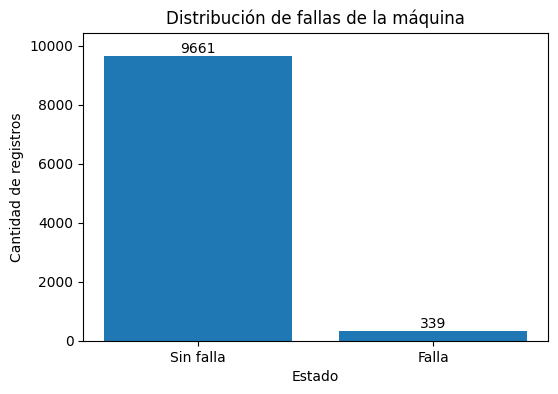

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
bars = plt.bar(["Sin falla", "Falla"], failure_counts.values)

plt.title("Distribución de fallas de la máquina")
plt.xlabel("Estado")
plt.ylabel("Cantidad de registros")

plt.ylim(0, failure_counts.max() * 1.08)

for bar, value in zip(bars, failure_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.show()

## 4. Comportamiento de las variables según el estado de falla

Se comparan las principales variables operativas de la máquina entre los registros con y sin falla, con el objetivo de identificar posibles diferencias asociadas a `Machine failure`.

In [13]:
variables = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

df.groupby("Machine failure")[variables].mean().T

Machine failure,0,1
Air temperature,299.973999,300.886431
Process temperature,309.995570,310.290265
Rotational speed,1540.260014,1496.486726
Torque,39.629655,50.168142
Tool wear,106.693717,143.781711


### 4.1 Distribución de torque según el estado de falla

Se analiza la distribución del torque para comparar los registros con y sin falla.

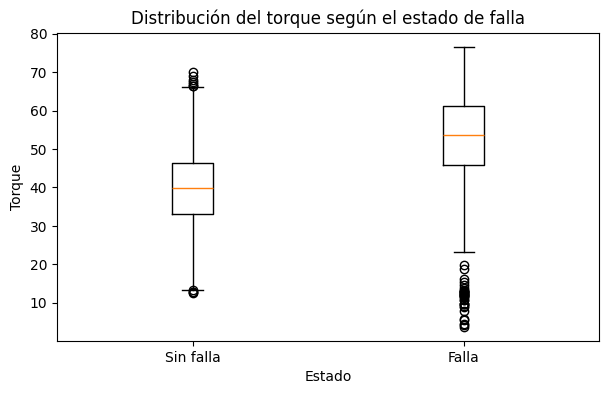

In [14]:
import matplotlib.pyplot as plt

sin_falla = df[df["Machine failure"] == 0]["Torque"]
con_falla = df[df["Machine failure"] == 1]["Torque"]

plt.figure(figsize=(7, 4))

plt.boxplot(
    [sin_falla, con_falla],
    tick_labels=["Sin falla", "Falla"]
)

plt.title("Distribución del torque según el estado de falla")
plt.xlabel("Estado")
plt.ylabel("Torque")

plt.show()

### 4.2 Distribución del desgaste de herramienta según el estado de falla

Se analiza la distribución del desgaste de la herramienta para comparar los registros con y sin falla.

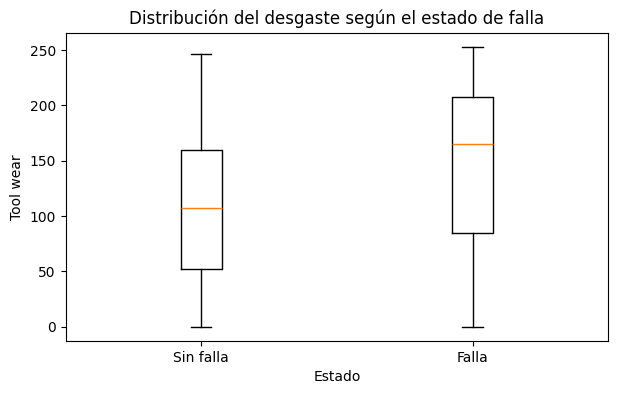

In [15]:
sin_falla = df[df["Machine failure"] == 0]["Tool wear"]
con_falla = df[df["Machine failure"] == 1]["Tool wear"]

plt.figure(figsize=(7, 4))

plt.boxplot(
    [sin_falla, con_falla],
    tick_labels=["Sin falla", "Falla"]
)

plt.title("Distribución del desgaste según el estado de falla")
plt.xlabel("Estado")
plt.ylabel("Tool wear")

plt.show()

## 5. Correlación entre variables

Se analiza la correlación entre las principales variables numéricas y la variable objetivo `Machine failure` para identificar relaciones lineales relevantes.

In [16]:
variables_correlacion = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear",
    "Machine failure"
]

correlaciones = df[variables_correlacion].corr()

correlaciones.round(3)

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure
Air temperature,1.000,0.876,0.023,-0.014,0.014,0.083
Process temperature,0.876,1.000,0.019,-0.014,0.013,0.036
Rotational speed,0.023,0.019,1.000,-0.875,0.000,-0.044
Torque,-0.014,-0.014,-0.875,1.000,-0.003,0.191
Tool wear,0.014,0.013,0.000,-0.003,1.000,0.105
Machine failure,0.083,0.036,-0.044,0.191,0.105,1.000


## 6. Revisión de variables con riesgo de fuga de información

Se analiza la relación entre `Machine failure` y las variables que identifican modos específicos de falla (`TWF`, `HDF`, `PWF`, `OSF` y `RNF`) antes de definir las características que serán utilizadas por los modelos.

In [17]:
failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]

df.groupby("Machine failure")[failure_modes].sum()

,TWF,HDF,PWF,OSF,RNF
Machine failure,,,,,
0,0,0,0,0,18
1,46,115,95,98,1


## 7. Definición preliminar de variables predictoras

A partir del análisis exploratorio, se definen las variables candidatas para la predicción de `Machine failure`. Se excluyen los identificadores (`UID` y `Product ID`) y los indicadores de modos de falla (`TWF`, `HDF`, `PWF`, `OSF` y `RNF`) para evitar información no apropiada para el escenario predictivo.

In [18]:
features = [
    "Type",
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

target = "Machine failure"

X = df[features].copy()
y = df[target].copy()

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

X.head()

Dimensiones de X: (10000, 6)
Dimensiones de y: (10000,)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


## 8. Análisis de la variable categórica `Type`

Se analiza la distribución de las categorías de `Type` antes de definir su tratamiento para el modelado.

In [19]:
print("Cantidad por categoría:")
print(df["Type"].value_counts())

print("\nPorcentaje por categoría:")
print(
    df["Type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Cantidad por categoría:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Porcentaje por categoría:
Type
L    60.00
M    29.97
H    10.03
Name: proportion, dtype: float64


## 9. Tasa de fallas según `Type`

Se analiza la proporción de fallas para cada categoría de `Type` con el objetivo de identificar diferencias entre los tipos de producto.

In [20]:
failure_by_type = (
    df.groupby("Type")["Machine failure"]
    .agg(["count", "sum", "mean"])
)

failure_by_type["failure_rate_%"] = (
    failure_by_type["mean"] * 100
).round(2)

failure_by_type

,count,sum,mean,failure_rate_%
Type,,,,
H,1003,21,0.020937,2.09
L,6000,235,0.039167,3.92
M,2997,83,0.027694,2.77


## 10. Conclusiones del análisis exploratorio

El dataset AI4I 2020 contiene 10 000 registros y no presenta valores faltantes ni registros duplicados.

La variable objetivo `Machine failure` presenta un desbalance considerable: el 96.61 % de los registros corresponde a máquinas sin falla y el 3.39 % a máquinas con falla. Debido a este desbalance, la evaluación de los modelos no debe depender únicamente de accuracy; se considerarán especialmente métricas como precision, recall, F1-score y PR-AUC.

El análisis exploratorio muestra diferencias en variables como `Torque` y `Tool wear` entre los registros con y sin falla. Asimismo, la tasa observada de fallas varía entre las categorías de `Type`.

Para el modelado se considerarán inicialmente `Type`, `Air temperature`, `Process temperature`, `Rotational speed`, `Torque` y `Tool wear` como variables predictoras.

Se excluirán `UID` y `Product ID` por ser identificadores. También se excluirán `TWF`, `HDF`, `PWF`, `OSF` y `RNF` del conjunto de predictores, ya que representan modos específicos de falla y su utilización podría introducir fuga de información respecto de la variable objetivo `Machine failure`.